In [1]:
# Sel 1: Import Library dan Redam Log
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.applications import EfficientNetB3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# Sel 2: Konfigurasi Sumber Data Hasil Augmentasi
AUG_DIR = '../data/augmented/'
CLASSES = ['healthy', 'sick']
IMG_SIZE = 224

In [3]:
# Sel 3: Fungsi Load dan Preprocessing Gambar Berukuran Besar
def load_augmented_data():
    X, y = [], []
    for label_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(AUG_DIR, class_name)
        for img_name in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, img_name))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img_resized / 255.0)
            y.append(label_idx)
    return np.array(X), np.array(y)

print("Memuat dan memproses dataset hasil augmentasi...")
X_data, y_data = load_augmented_data()
print(f"Total data terload: {X_data.shape[0]} gambar.")

Memuat dan memproses dataset hasil augmentasi...
Total data terload: 1400 gambar.


In [4]:
# Sel 4: Ekstraksi Fitur via EfficientNet-B3
print("Membangun model EfficientNet-B3...")
feature_extractor = EfficientNetB3(weights='imagenet', include_top=False, pooling='avg')
print("Mengekstraksi fitur dari dataset augmented (Proses GPU)...")
X_features = feature_extractor.predict(X_data, batch_size=16)
print(f"Dimensi fitur hasil ekstraksi: {X_features.shape}")

Membangun model EfficientNet-B3...
Mengekstraksi fitur dari dataset augmented (Proses GPU)...
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 587ms/step
Dimensi fitur hasil ekstraksi: (1400, 1536)


In [5]:
# Sel 5: Split Data Latih dan Uji
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_data, test_size=0.2, random_state=42, stratify=y_data
)

In [6]:
# Sel 6: Normalisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Sel 7: Inisialisasi Model Klasifikasi Klasik (Persis seperti Notebook 02)
models = {
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='euclidean')
}


Training SVM (RBF) dengan Data Augmented...


/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Akurasi Seteleh Augmentasi: 0.8393
Macro F1-Score: 0.8392

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.86      0.84       140
        Sick       0.86      0.81      0.84       140

    accuracy                           0.84       280
   macro avg       0.84      0.84      0.84       280
weighted avg       0.84      0.84      0.84       280



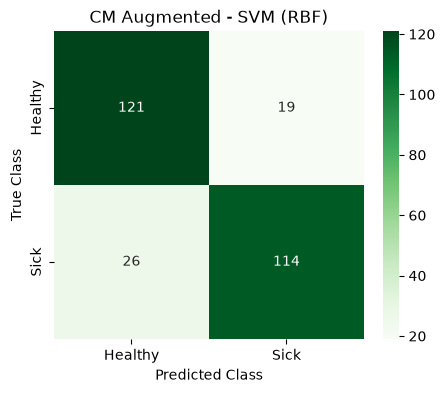

>>> Model SVM (RBF) Versi Teraugmentasi Berhasil Disimpan! <<<

Training Random Forest dengan Data Augmented...
Akurasi Seteleh Augmentasi: 0.8429
Macro F1-Score: 0.8427

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.88      0.85       140
        Sick       0.87      0.81      0.84       140

    accuracy                           0.84       280
   macro avg       0.84      0.84      0.84       280
weighted avg       0.84      0.84      0.84       280



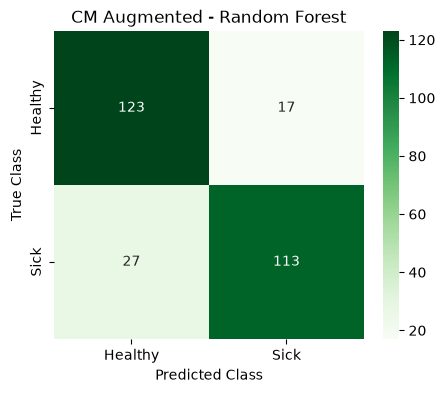


Training KNN dengan Data Augmented...
Akurasi Seteleh Augmentasi: 0.7750
Macro F1-Score: 0.7750

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.77      0.78      0.78       140
        Sick       0.78      0.77      0.77       140

    accuracy                           0.78       280
   macro avg       0.78      0.78      0.77       280
weighted avg       0.78      0.78      0.77       280



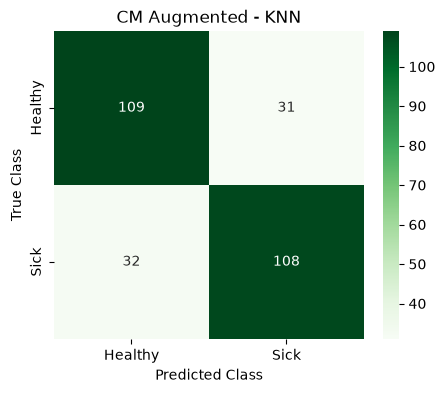

In [8]:
# Sel 8: Pelatihan, Evaluasi, dan Penyimpanan Model Baru
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name} dengan Data Augmented...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"Akurasi Seteleh Augmentasi: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1-Score: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sick']))
    
    # Cetak Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Menggunakan warna hijau sebagai pembeda visual
                xticklabels=['Healthy', 'Sick'], yticklabels=['Healthy', 'Sick'])
    plt.title(f'CM Augmented - {name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    # Overwrite simpan model terbaik versi augmented agar bisa langsung ditarik oleh Streamlit
    if name == "SVM (RBF)":
        joblib.dump(model, '../models/svm_model.pkl')
        joblib.dump(scaler, '../models/scaler.pkl')
        feature_extractor.save('../models/efficientnet_extractor.keras')
        print(f">>> Model {name} Versi Teraugmentasi Berhasil Disimpan! <<<")